# NB04: Core vs Accessory Interaction

**Goal**: Test whether the copy number variation pattern differs between core and accessory (auxiliary + singleton) gene clusters. The `raw` extraction already keeps `is_core` — we can split rates within each COG × class × core-status.

**Motivating question**: Do core L genes (mobile elements that reached fixation across the species) show less copy number variation than accessory L genes? Are accessory-adaptive clusters where paralog expansion happens most?

**Inputs**: `data/multi_species_copy_stats.csv` (already has is_core split)
**Outputs**: `data/core_accessory_stats.csv`, `figures/core_accessory_interaction.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

raw = pd.read_csv(DATA_DIR / 'multi_species_copy_stats.csv')
print(f'Loaded {len(raw):,} rows')
print(f'is_core value counts: {raw["is_core"].value_counts().to_dict()}')

Loaded 2,768 rows
is_core value counts: {True: 1387, False: 1381}


In [2]:
# Filter to single-letter COGs
single = raw[
    raw['COG_category'].notna() &
    (raw['COG_category'].str.len() == 1) &
    (raw['COG_category'] != '-')
].copy()

HOUSEKEEPING = {'F', 'H'}
ADAPTIVE = {'L', 'V', 'M', 'K'}
MIXED = {'C', 'J'}

def classify(c):
    if c in HOUSEKEEPING: return 'housekeeping'
    if c in ADAPTIVE: return 'adaptive'
    if c in MIXED: return 'mixed'
    return 'other'

single['class'] = single['COG_category'].apply(classify)

# Aggregate to per-species per-(class, is_core)
species_class_core = single[single['class'].isin(['adaptive', 'housekeeping'])].groupby(
    ['species_prefix', 'phylum', 'class', 'is_core']).apply(
    lambda g: pd.Series({
        'total_carriers': g['total_carriers'].sum() if 'total_carriers' in g.columns else g['total_carrier_genomes'].sum(),
        'total_multicopy': g['total_multicopy_genomes'].sum(),
    })
).reset_index()
species_class_core['rate_pct'] = 100 * species_class_core['total_multicopy'] / species_class_core['total_carriers']
species_class_core['status'] = np.where(species_class_core['is_core'], 'core', 'accessory')
print(species_class_core.head())

              species_prefix            phylum         class  is_core  \
0  s__Aliarcobacter_butzleri  Campylobacterota      adaptive    False   
1  s__Aliarcobacter_butzleri  Campylobacterota      adaptive     True   
2  s__Aliarcobacter_butzleri  Campylobacterota  housekeeping    False   
3  s__Aliarcobacter_butzleri  Campylobacterota  housekeeping     True   
4    s__Bacillus_altitudinis         Bacillota      adaptive    False   

   total_carriers  total_multicopy  rate_pct     status  
0            8854               70  0.790603  accessory  
1           20839                9  0.043188       core  
2             706                3  0.424929  accessory  
3           13668               11  0.080480       core  
4           12572              194  1.543112  accessory  


In [3]:
# 2x2 grouping: class × status
summary_2x2 = species_class_core.groupby(['class', 'status'])['rate_pct'].agg(['mean', 'median', 'std', 'count']).reset_index()
print('Per (class × status) rate summary:')
print(summary_2x2.to_string())
summary_2x2.to_csv(DATA_DIR / 'core_accessory_stats.csv', index=False)

Per (class × status) rate summary:
          class     status      mean    median       std  count
0      adaptive  accessory  2.087075  1.547559  1.642120     24
1      adaptive       core  0.195546  0.062424  0.280379     24
2  housekeeping  accessory  0.455285  0.293442  0.644224     24
3  housekeeping       core  0.058468  0.028576  0.066422     24


## 3. Statistical tests — 4 pairings

In [4]:
# Test 1: Within adaptive, accessory > core?
ad_core = species_class_core[(species_class_core['class'] == 'adaptive') & (species_class_core['status'] == 'core')].set_index('species_prefix')['rate_pct']
ad_acc = species_class_core[(species_class_core['class'] == 'adaptive') & (species_class_core['status'] == 'accessory')].set_index('species_prefix')['rate_pct']
idx = ad_core.index.intersection(ad_acc.index)
w1, p1 = stats.wilcoxon(ad_acc.loc[idx], ad_core.loc[idx], alternative='greater')
print(f'H4a — adaptive_accessory > adaptive_core: median {ad_acc.loc[idx].median():.3f}% vs {ad_core.loc[idx].median():.3f}% '
      f'(n={len(idx)}, Wilcoxon p={p1:.2e})')

# Test 2: Within housekeeping, accessory > core?
hk_core = species_class_core[(species_class_core['class'] == 'housekeeping') & (species_class_core['status'] == 'core')].set_index('species_prefix')['rate_pct']
hk_acc = species_class_core[(species_class_core['class'] == 'housekeeping') & (species_class_core['status'] == 'accessory')].set_index('species_prefix')['rate_pct']
idx = hk_core.index.intersection(hk_acc.index)
w2, p2 = stats.wilcoxon(hk_acc.loc[idx], hk_core.loc[idx], alternative='greater')
print(f'H4b — housekeeping_accessory > housekeeping_core: median {hk_acc.loc[idx].median():.3f}% vs {hk_core.loc[idx].median():.3f}% '
      f'(n={len(idx)}, Wilcoxon p={p2:.2e})')

# Test 3: Within core, adaptive > housekeeping?
idx = ad_core.index.intersection(hk_core.index)
w3, p3 = stats.wilcoxon(ad_core.loc[idx], hk_core.loc[idx], alternative='greater')
print(f'H4c — adaptive_core > housekeeping_core: median {ad_core.loc[idx].median():.3f}% vs {hk_core.loc[idx].median():.3f}% '
      f'(n={len(idx)}, Wilcoxon p={p3:.2e})')

# Test 4: Within accessory, adaptive > housekeeping?
idx = ad_acc.index.intersection(hk_acc.index)
w4, p4 = stats.wilcoxon(ad_acc.loc[idx], hk_acc.loc[idx], alternative='greater')
print(f'H4d — adaptive_accessory > housekeeping_accessory: median {ad_acc.loc[idx].median():.3f}% vs {hk_acc.loc[idx].median():.3f}% '
      f'(n={len(idx)}, Wilcoxon p={p4:.2e})')

H4a — adaptive_accessory > adaptive_core: median 1.548% vs 0.062% (n=24, Wilcoxon p=5.96e-08)
H4b — housekeeping_accessory > housekeeping_core: median 0.293% vs 0.029% (n=24, Wilcoxon p=1.23e-04)
H4c — adaptive_core > housekeeping_core: median 0.062% vs 0.029% (n=24, Wilcoxon p=4.92e-04)
H4d — adaptive_accessory > housekeeping_accessory: median 1.548% vs 0.293% (n=24, Wilcoxon p=3.28e-06)


## 4. Figure — 2×2 interaction plot

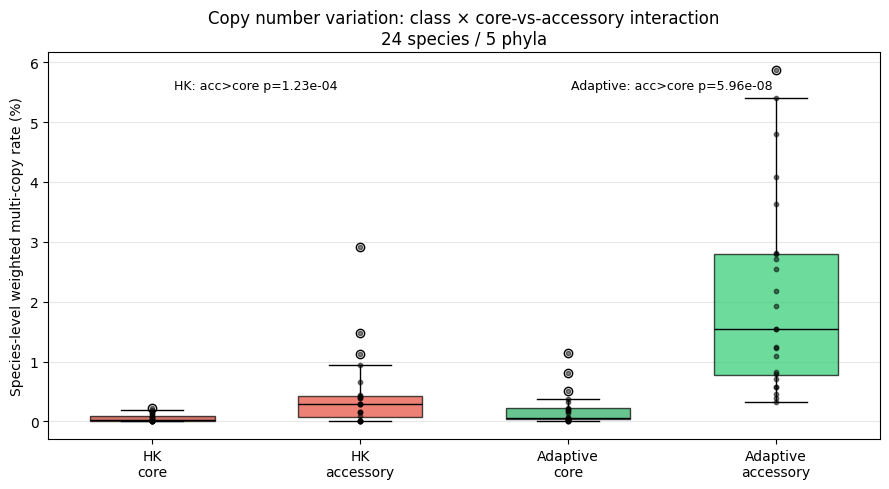

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = [('housekeeping', 'core'), ('housekeeping', 'accessory'), ('adaptive', 'core'), ('adaptive', 'accessory')]
labels = ['HK\ncore', 'HK\naccessory', 'Adaptive\ncore', 'Adaptive\naccessory']
positions = np.arange(4)
colors = ['#c0392b', '#e74c3c', '#27ae60', '#2ecc71']

for i, (cls, status) in enumerate(categories):
    subset = species_class_core[(species_class_core['class'] == cls) & (species_class_core['status'] == status)]['rate_pct']
    bp = ax.boxplot([subset], positions=[i], widths=0.6, patch_artist=True, showfliers=True,
                    medianprops={'color': 'black'})
    for patch in bp['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7)
    ax.scatter([i] * len(subset), subset, color='black', s=10, zorder=3, alpha=0.5)

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Species-level weighted multi-copy rate (%)')
ax.set_title(f'Copy number variation: class × core-vs-accessory interaction\n'
             f'{species_class_core["species_prefix"].nunique()} species / 5 phyla')
ax.grid(axis='y', alpha=0.3)

# Add p-value annotations
ax.text(0.5, ax.get_ylim()[1] * 0.9, f'HK: acc>core p={p2:.2e}', ha='center', fontsize=9)
ax.text(2.5, ax.get_ylim()[1] * 0.9, f'Adaptive: acc>core p={p1:.2e}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'core_accessory_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Verdict on core/accessory interaction

In [6]:
print('=' * 70)
print('H4 (core vs accessory interaction)')
print('=' * 70)
print(f'  Adaptive: accessory > core → p = {p1:.2e} {"✅ SUPPORTED" if p1 < 0.05 else "❌ NOT SUPPORTED"}')
print(f'  Housekeeping: accessory > core → p = {p2:.2e} {"✅ SUPPORTED" if p2 < 0.05 else "❌ NOT SUPPORTED"}')
print(f'  Core: adaptive > housekeeping → p = {p3:.2e} {"✅ SUPPORTED" if p3 < 0.05 else "❌ NOT SUPPORTED"}')
print(f'  Accessory: adaptive > housekeeping → p = {p4:.2e} {"✅ SUPPORTED" if p4 < 0.05 else "❌ NOT SUPPORTED"}')

H4 (core vs accessory interaction)
  Adaptive: accessory > core → p = 5.96e-08 ✅ SUPPORTED
  Housekeeping: accessory > core → p = 1.23e-04 ✅ SUPPORTED
  Core: adaptive > housekeeping → p = 4.92e-04 ✅ SUPPORTED
  Accessory: adaptive > housekeeping → p = 3.28e-06 ✅ SUPPORTED
